## Пример решения задачи классификации

Задачи машинного обучения с учителем состоят в восстановлении зависимости между признаковым описанием и целевой переменной. Для классификации эта переменная категориальная, для регрессии - вещественная.
Помимо построения модели и самого обучения, требуется также определить критерий качества модели (метрику). 
Качество модели оценивается на контрольной (тестовой ) выборке или с помощью кросс-валидации.   

In [1]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [3]:
%pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn.datasets
wn_dataset = sklearn.datasets.load_wine()

In [3]:
wn_dataset.data.shape

(178, 13)

In [4]:
#train test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(wn_dataset.data[:,:2],wn_dataset.target,test_size=0.3, shuffle=True)

In [5]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [6]:
#архитектура сети
class ClassifierNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons=10):
        super(ClassifierNet, self).__init__()
        self.fc1 = torch.nn.Linear(2, n_hidden_neurons)
        self.fc2 = torch.nn.Linear(n_hidden_neurons, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

    def inference(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)


class_net = ClassifierNet()

In [7]:
loss = torch.nn.CrossEntropyLoss()

In [8]:
optimizer = torch.optim.Adam(class_net.parameters(), lr=0.01)

In [9]:
batch_size = 16

for epoch in range(5000):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        
        batch_indexes = order[start_index:start_index+batch_size]
        
        x_batch = X_train[batch_indexes]
        y_batch = y_train[batch_indexes]
        
        preds = class_net.forward(x_batch) 
        
        loss_value = loss(preds, y_batch)
        loss_value.backward()
        
        optimizer.step()
        
    if epoch % 100 == 0:
        test_preds = class_net.forward(X_test)
        test_preds = test_preds.argmax(dim=1)
        accuracy = (test_preds == y_test).float().mean()
        print(accuracy)
        if accuracy>0.85:
            print("Обучение завершено досрочно")
            break

tensor(0.5000)
tensor(0.7593)
tensor(0.7963)
tensor(0.8333)
tensor(0.7222)
tensor(0.7593)
tensor(0.8519)
Обучение завершено досрочно


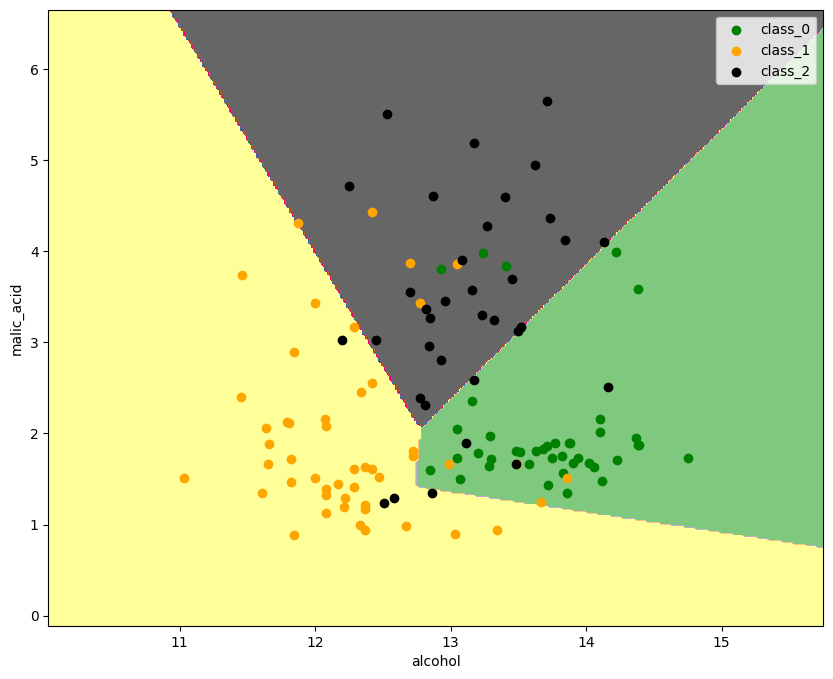

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

n_classes = 3
plot_colors = ['g', 'orange', 'black']
plot_step = 0.02

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
# формируем множество пар признаков, которые мы выбрали в самом начале (первые два)
xx, yy = torch.meshgrid(torch.arange(x_min, x_max, plot_step),
                        torch.arange(y_min, y_max, plot_step), indexing='xy')

# подаем на вход сети набор комбинаций признаков (первого и второго)
input_data = torch.cat([xx.reshape(-1, 1), yy.reshape(-1, 1)], dim=1)
preds = class_net.inference(input_data)
#preds = class_net.forward(input_data)
# определяем номер класса по индексу максимального значения выходноого нейрона]
preds_class = preds.data.numpy().argmax(axis=1)
preds_class = preds_class.reshape(xx.shape)
plt.contourf(xx, yy, preds_class, cmap='Accent')

for i, color in zip(range(n_classes), plot_colors):
    indexes = np.where(y_train.numpy() == i)[0]
    plt.scatter(X_train[indexes, 0].numpy(), 
                X_train[indexes, 1].numpy(), 
                c=color, 
                label=wn_dataset.target_names[i])
    plt.xlabel(wn_dataset.feature_names[0])
    plt.ylabel(wn_dataset.feature_names[1])
    plt.legend()

# Задание

Измените архитектуру так, чтобы на вход принимались все 13 признаков и проведите следующие эксперименты:

1. Поэкспериментируйте с количеством нейронов в скрытых слоях. Попробуйте поставить очень маленькое число. Существует ли пороговое значение количества скрытых нейронов, при котором обучение становится невозможным?

2. Попробуйте передавать различные значения test_size в функцию train_test_split. При каком значении test_size сеть предсказывает хуже чем Base Rate*? И какой Base Rate у датасета вин?

3. Зависит ли время обучения на одной эпохе от размера батча? Исследуйте эту зависимость.

<hr>
*Base Rate - значение accuracy для случая, когда модель для всех объектов предсказывает самый частотный класс в датасете

- Random Rate Classifier - случайное угадывание, учитываются априорные вероятности классов (Weighted Guessing)
- Zero Rate Classifier - Классификатор тривиально предсказывает наиболее часто встречающийся класс.


Пример.
Пусть распределение в выборке по классам следующее:
- 1 класс =  0.6
- 2 класс =  0.3
- 3 класс =  0.1

Random Rate baseline
$0.6*0.6+0.3*0.3+0.1*0.1 = 0.459$

Zero Rule baseline = $0.6$

Соответственно, ваша модель должна показывать результаты выше Base Rate.

In [11]:
# Base Rate: распределение классов и базовые вероятности
import numpy as np

unique, counts = np.unique(wn_dataset.target, return_counts=True)
class_probs = counts / counts.sum()

print("Метки классов:", unique)
print("Частоты классов:", counts)
print("Вероятности классов:", class_probs)


Метки классов: [0 1 2]
Частоты классов: [59 71 48]
Вероятности классов: [0.33146067 0.3988764  0.26966292]


In [12]:
#ZeroR
baserate = class_probs.max()
print("ZeroR (Base Rate) accuracy:", baserate)


ZeroR (Base Rate) accuracy: 0.398876404494382


In [13]:
#RandomR
random_rate = (class_probs ** 2).sum()
print("RandomR accuracy:", random_rate)


RandomR accuracy: 0.34168665572528717


In [14]:
#features =  13 # кол-во признаков
#wn_dataset.data[:, :features],

X_train, X_test, y_train, y_test = train_test_split(
    wn_dataset.data[:, :13], 
    wn_dataset.target, 
    test_size=0.3, 
    shuffle=True)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [15]:
#архитектура сети
class ClassifierNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super(ClassifierNet, self).__init__()
        self.fc1 = torch.nn.Linear(13, n_hidden_neurons)
        self.fc2 = torch.nn.Linear(n_hidden_neurons, 3)

    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

    def inference(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)


class_net = ClassifierNet(n_hidden_neurons=20)

In [16]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(class_net.parameters(), lr=0.01)
batch_size = 16

for epoch in range(5000):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()
        
        batch_indexes = order[start_index:start_index+batch_size]
        
        x_batch = X_train[batch_indexes]
        y_batch = y_train[batch_indexes]
        
        preds = class_net.forward(x_batch) 
        
        loss_value = loss(preds, y_batch)
        loss_value.backward()
        
        optimizer.step()
        
    if epoch % 100 == 0:
        test_preds = class_net.forward(X_test)
        test_preds = test_preds.argmax(dim=1)
        accuracy = (test_preds == y_test).float().mean()
        print(accuracy)


tensor(0.3333)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9630)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9630)
tensor(0.9630)
tensor(0.9630)
tensor(0.9815)
tensor(0.9630)
tensor(0.9630)
tensor(0.9444)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9630)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9630)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)
tensor(0.9815)


### Автопроверка

In [17]:
print(class_net .fc1.in_features, np.asarray((test_preds == y_test).float().mean()) > 0.9)
# должно быть 13 True

13 True


In [18]:
# Эксперимент 1: влияние числа нейронов в скрытом слое
import math

def train_model(n_hidden_neurons, epochs=1000, batch_size=16, lr=0.01):
    model = ClassifierNet(n_hidden_neurons)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        order = np.random.permutation(len(X_train))
        for start_index in range(0, len(X_train), batch_size):
            batch_indexes = order[start_index:start_index + batch_size]
            x_batch = X_train[batch_indexes]
            y_batch = y_train[batch_indexes]

            optimizer.zero_grad()
            logits = model(x_batch)
            loss_value = loss_fn(logits, y_batch)
            loss_value.backward()
            optimizer.step()

    with torch.no_grad():
        preds_local = model(X_test).argmax(dim=1)
        acc = (preds_local == y_test).float().mean().item()
    return acc

hidden_neurons_list = [1, 2, 3, 4, 5, 10, 20, 50]
for n in hidden_neurons_list:
    acc = train_model(n_hidden_neurons=n)
    print(f"Скрытых нейронов: {n:2d}, accuracy: {acc:.3f}")

Скрытых нейронов:  1, accuracy: 0.333
Скрытых нейронов:  2, accuracy: 0.333
Скрытых нейронов:  3, accuracy: 0.333
Скрытых нейронов:  4, accuracy: 0.944
Скрытых нейронов:  5, accuracy: 0.981
Скрытых нейронов: 10, accuracy: 0.963
Скрытых нейронов: 20, accuracy: 0.981
Скрытых нейронов: 50, accuracy: 0.981


In [19]:
# Эксперимент 2: влияние test_size на качество и сравнение с Base Rate (ZeroR)

def evaluate_for_test_size(test_size, n_hidden_neurons=20, epochs=500, batch_size=16, lr=0.01):
    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        wn_dataset.data[:, :13],
        wn_dataset.target,
        test_size=test_size,
        shuffle=True,
    )

    X_train_local = torch.FloatTensor(X_train_local)
    X_test_local = torch.FloatTensor(X_test_local)
    y_train_local = torch.LongTensor(y_train_local)
    y_test_local = torch.LongTensor(y_test_local)

    model = ClassifierNet(n_hidden_neurons)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        order = np.random.permutation(len(X_train_local))
        for start_index in range(0, len(X_train_local), batch_size):
            batch_indexes = order[start_index:start_index + batch_size]
            x_batch = X_train_local[batch_indexes]
            y_batch = y_train_local[batch_indexes]

            optimizer.zero_grad()
            logits = model(x_batch)
            loss_value = loss_fn(logits, y_batch)
            loss_value.backward()
            optimizer.step()

    with torch.no_grad():
        preds_local = model(X_test_local).argmax(dim=1)
        acc = (preds_local == y_test_local).float().mean().item()
    return acc

print("ZeroR (Base Rate) accuracy:", float(baserate))

for ts in [0.1, 0.2, 0.3, 0.4, 0.5]:
    acc = evaluate_for_test_size(ts)
    print(f"test_size={ts:.1f}, accuracy={acc:.3f}, лучше Base Rate? {acc > baserate}")

ZeroR (Base Rate) accuracy: 0.398876404494382
test_size=0.1, accuracy=1.000, лучше Base Rate? True
test_size=0.2, accuracy=0.917, лучше Base Rate? True
test_size=0.3, accuracy=0.926, лучше Base Rate? True
test_size=0.4, accuracy=0.931, лучше Base Rate? True
test_size=0.5, accuracy=0.888, лучше Base Rate? True


In [20]:
# Эксперимент 3: зависимость времени одной эпохи от размера батча
import time


def time_for_batch_size(batch_size, n_hidden_neurons=20, lr=0.01):
    model = ClassifierNet(n_hidden_neurons)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        batch_indexes = order[start_index:start_index + batch_size]
        x_batch = X_train[batch_indexes]
        y_batch = y_train[batch_indexes]

        optimizer.zero_grad()
        logits = model(x_batch)
        loss_value = loss_fn(logits, y_batch)
        loss_value.backward()
        optimizer.step()
    end = time.time()

    return end - start

batch_sizes = [4, 8, 16, 32, 64, len(X_train)]
for b in batch_sizes:
    t = time_for_batch_size(b)
    print(f"batch_size={b:3d}, время за эпоху: {t:.4f} сек")

batch_size=  4, время за эпоху: 0.0133 сек
batch_size=  8, время за эпоху: 0.0054 сек
batch_size= 16, время за эпоху: 0.0025 сек
batch_size= 32, время за эпоху: 0.0014 сек
batch_size= 64, время за эпоху: 0.0011 сек
batch_size=124, время за эпоху: 0.0004 сек
